## Imports

In [3]:
from bs4 import BeautifulSoup
import networkx as nx
import matplotlib.pyplot as plt

## Parse all Azuki transactions

In [5]:
all_transactions = []


cnt = 1
date_ = "feb_23"
base_path = "../../nft_analytics/data"
## Read data
fn = "{}/azuki_{}_{}.html".format(base_path, date_, cnt)


fn = "../data/azuki_{}_{}.html".format(date_, cnt)

while cnt < 220:
    with open(fn, "r") as fp:
        print("Parsing {} ...".format(fn))
        html = fp.read()
        soup = BeautifulSoup(html)
        lisitem_divs = soup.findAll('div', {'role': 'listitem'})
        for item in lisitem_divs:
            divs = item.findAll('div', {'display': 'flex'})
            data = {}
            data["azuki_id"] = divs[1].text
            prices = divs[2].text.split(" ")
            try:
                data["eth"] = prices[0]
            except IndexError:
                data["eth"] = -1
            try:
                data["usd"] = prices[1]
            except IndexError:
                data["usd"] = -1
            data["cnt"] = divs[3].text
            data["sender"] = divs[4].text
            data["receiver"] = divs[5].text
            data["date"] = divs[6].text
            all_transactions.append(data)
    cnt += 1
    # proceed to next file
    fn = "{}/azuki_{}_{}.html".format(base_path, date_, cnt)


Parsing ../data/azuki_feb_23_1.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_2.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_3.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_4.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_5.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_6.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_7.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_8.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_9.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_10.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_11.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_12.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_13.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_14.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_15.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_16.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_17.html ...
Parsing ../../nft_analytics/data/azuki_f

Parsing ../../nft_analytics/data/azuki_feb_23_142.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_143.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_144.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_145.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_146.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_147.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_148.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_149.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_150.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_151.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_152.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_153.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_154.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_155.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_156.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_157.html ...
Parsing ../../nft_analytics/data/azuki_feb_23_158.html .

## Review data

In [6]:
print("No of transactions: {}".format(len(all_transactions)))

No of transactions: 3058


## Find hubs

In [7]:
azuki_freqs = {}

for trans in all_transactions:
    try:
        items = trans["azuki_id"].split(" #")
        azuki_id = items[1].strip()
    except IndexError:
        continue
    try:
        azuki_freqs[azuki_id] += 1
    except KeyError:
        azuki_freqs[azuki_id] = 1

In [8]:
sorted_azukis = {k: v for k, v in sorted(azuki_freqs.items(), key=lambda item: item[1], reverse=True)} 

In [9]:
k = 10

hub_azukis = []
cnt = 1

for azuki_id in sorted_azukis.keys():
    hub_azukis.append(azuki_id)
    if cnt >= k:
        break
    cnt += 1

In [10]:
hub_azukis

['6421',
 '1287',
 '1500',
 '1309',
 '3781',
 '5292',
 '3563',
 '9059',
 '2693',
 '8075']

In [11]:
interesting_azukis = ["9166", "6609", "4994", "2877", "5222", "6954"]

## Generate Graph

In [12]:
g = nx.Graph()

for trans in all_transactions:
    try:
        items = trans["azuki_id"].split(" #")
        azuki_id = items[1].strip()
    except IndexError:
        continue

    #if azuki_id in set(hub_azukis):
    #if azuki_id in set(interesting_azukis):
        #print(azuki_id)
    sendr, rcvr = trans["sender"], trans["receiver"]
    g.add_edge(sendr, rcvr)

## Draw graph

//anaconda/envs/uatu/lib/python3.7/site-packages/networkx/drawing/nx_pylab.py:579: MatplotlibDeprecationWarning: 
The iterable function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use np.iterable instead.
  if not cb.iterable(width):
//anaconda/envs/uatu/lib/python3.7/site-packages/matplotlib/backends/backend_agg.py:211: RuntimeWarning: Glyph 127948 missing from current font.
  font.set_text(s, 0.0, flags=flags)
//anaconda/envs/uatu/lib/python3.7/site-packages/matplotlib/backends/backend_agg.py:211: RuntimeWarning: Glyph 127995 missing from current font.
  font.set_text(s, 0.0, flags=flags)
//anaconda/envs/uatu/lib/python3.7/site-packages/matplotlib/backends/backend_agg.py:180: RuntimeWarning: Glyph 127948 missing from current font.
  font.set_text(s, 0, flags=flags)
//anaconda/envs/uatu/lib/python3.7/site-packages/matplotlib/backends/backend_agg.py:180: RuntimeWarning: Glyph 127995 missing from current font.
  font.set_text(s, 0, flags=flags)
//anaconda/envs/uatu/lib/

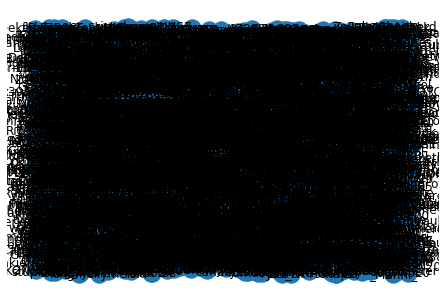

In [13]:
# clearing the current plot
plt.clf()
 
# drawing in random layout
nx.draw_random(g, with_labels = True)

# # drawing in circular layout
# nx.draw_circular(g, with_labels = True)

plt.savefig("azuki_2.png")

In [14]:
g.degree

DegreeView({'viat': 8, 'juju7': 1, 'ZhangKai666': 1, 'CiffoVault': 15, 'QuickNick1': 1, 'GK88': 5, 'deeze': 1, 'McDIntern': 1, '8C75D3': 3, '33A21B': 1, 'Haojian': 3, 'ChadCloutman': 4, '0-----0-0-0-0-0-0-0-0': 1, 'E7BD48': 2, 'AustinsVault': 3, 'KeqingNFT': 11, 'jjj123jjj123': 1, 'clonemoon': 2, 'freshcow': 2, 'CaptainHodl': 1, '3E184E': 2, 'davincenzo': 1, 'E4AF24': 7, '844802': 1, 'jshilla': 3, 'xCryptorcitox': 2, 'Wizard98': 1, '0x0688a': 1, 'QEPS': 1, 'mehidfk': 1, 'z3th': 2, 'CryptoRat6': 1, 'hunnit': 7, 'LakeShowTJ': 2, 'Benjamin_0': 1, 'literallyno': 1, 'a_safari25': 4, 'albertslund8': 1, 'B9CF05': 2, 'Crypto_SEA': 1, '054882': 12, 'BryantChaoTrader': 4, 'tOOsmol': 3, 'MrWoonderful': 1, 'OxyJPEGS': 4, 'milhouse.eth': 1, 'IronKingdoms': 1, 'weiwei666': 1, '000000': 81, '4A174D': 2, 'Dutchy007': 1, 'kywong99': 1, 'artjemm': 2, 'lalong': 1, 'keithloh': 1, 'xinjing85': 1, '50425A': 1, 'centnas': 3, 'BA6C43': 2, 'virg77777': 2, 'h4x': 15, '533D56': 2, 'E407A1': 1, 'MrSpaghettiHands'

In [15]:
sorted(g.degree, key=lambda x: x[1], reverse=True)[:10]

[('F24629', 103),
 ('000000', 81),
 ('0A267C', 76),
 ('shiruko', 17),
 ('CiffoVault', 15),
 ('h4x', 15),
 ('KoalaVault', 15),
 ('3E0DEF', 14),
 ('0B76B9', 14),
 ('Formosa', 13)]